In [218]:
# imports
import pandas as pd
import numpy as np
import networkx as nx
import random

import seaborn as sns
import matplotlib.pyplot as plt

In [219]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country"]]
nodes[" id"] = np.arange(0, 3214)

In [220]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

In [221]:
A = np.zeros((3214, 3214))

for source, target, distance in edges.values:
    A[int(source)][int(target)] = distance

G = nx.from_numpy_array(A, create_using=nx.DiGraph) # directed graph

In [222]:
G.number_of_nodes(), G.number_of_edges()


(3214, 36906)

**Asortativity**

V sieti neexistuje výrazná tendencia, aby sa letiská pripájali k letiskám s podobným alebo odlišným počtom spojení.

In [223]:
r = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity coefficient: {r:.4f}") # approx. 0

Degree assortativity coefficient: -0.0192


**Density**

- existuje iba ~0.36 % všetkých možných spojení

In [224]:
density = nx.density(G)
print(f"Density: {density:.6f}") 

Density: 0.003574


**Reciprocita**

- skoro všetky letecké spojenia sú obojsmerné, sieť je skoro úplne symetrická

In [225]:
reciprocity = nx.reciprocity(G)
print(f"Reciprocity: {reciprocity:.4f}") 

Reciprocity: 0.9781


**Articulations**

In [226]:
# Bridges and articulation points require undirected graphs
G_undirected = G.to_undirected()

In [227]:
articulation_points = list(nx.articulation_points(G_undirected))
print(f"Number of articulation points: {len(articulation_points)}")
print(articulation_points[:10]) # first 10 articulation points

Number of articulation points: 333
[34, 113, 2287, 2330, 2292, 57, 156, 216, 254, 261]


In [228]:
def match_id(array, nodes_df, top_n=333):
    id_to_name = dict(zip(nodes_df[" id"].astype(int), nodes_df[" name"]))
    centrality_list = [(int(i), id_to_name.get(int(i), "Unknown")) for i in array]
    centrality_list_sorted = sorted(centrality_list, key=lambda x: x[1], reverse=True)
    for i, (nid, name) in enumerate(centrality_list_sorted[:top_n], 1):
        print(f"{i}. {name} (id={nid})")

In [229]:
match_id(articulation_points, nodes)

1. Ürümqi Diwopu International Airport (id=1675)
2. Zamboanga International Airport (id=1120)
3. Zagreb Airport (id=564)
4. Yuzhno-Sakhalinsk Airport (id=1395)
5. Yemelyanovo Airport (id=2222)
6. Yellowknife Airport (id=126)
7. Yangon International Airport (id=1557)
8. Yakutsk Airport (id=1388)
9. Xining Caojiabu Airport (id=2790)
10. Wuhan Tianhe International Airport (id=1652)
11. Wilwal International Airport (id=3069)
12. Wiley Post Will Rogers Memorial Airport (id=1752)
13. Wellington International Airport (id=959)
14. Wattay International Airport (id=1506)
15. Washington Dulles International Airport (id=1829)
16. Vnukovo International Airport (id=1437)
17. Viracopos International Airport (id=1199)
18. Vilhelmina Airport (id=363)
19. Venetie Airport (id=2987)
20. Vancouver International Airport (id=97)
21. Val de Cans/Júlio Cezar Ribeiro International Airport (id=1167)
22. Upernavik Airport (id=2267)
23. Unalaska Airport (id=1903)
24. Unalakleet Airport (id=2973)
25. Tupelo Regiona

**Bridges**

In [230]:
bridges = list(nx.bridges(G_undirected))
print(f"Number of bridges: {len(bridges)}")

Number of bridges: 757


In [231]:
id_to_name = dict(zip(
    nodes[" id"].astype(int),
    nodes[" name"]
))

In [232]:
def map_bridges(bridge_list, id_to_name, top_n=None):
    mapped = []
    for u, v in bridge_list:

        mapped.append((int(u),id_to_name.get(int(u), "Unknown"),int(v),id_to_name.get(int(v), "Unknown")))

    mapped_sorted = sorted(mapped, key=lambda x: x[1])

    if top_n:
        mapped_sorted = mapped_sorted[:top_n]

    for i, (u_id, u_name, v_id, v_name) in enumerate(mapped_sorted, 1):
        print(f"{i}. " f"{u_name} (id={u_id}) "f"<--> "f"{v_name} (id={v_id})")

In [233]:
map_bridges(bridges, id_to_name, top_n=10)

1. Abu Simbel Airport (id=522) <--> Aswan International Airport (id=526)
2. Addis Ababa Bole International Airport (id=508) <--> Mekele Airport (id=517)
3. Adelaide International Airport (id=1627) <--> Kingscote Airport (id=2034)
4. Adelaide International Airport (id=1627) <--> Coober Pedy Airport (id=2714)
5. Adelaide International Airport (id=1627) <--> Ceduna Airport (id=2716)
6. Adelaide International Airport (id=1627) <--> Olympic Dam Airport (id=2749)
7. Adelaide International Airport (id=1627) <--> Port Augusta Airport (id=2750)
8. Adelaide International Airport (id=1627) <--> Port Lincoln Airport (id=2755)
9. Adelaide International Airport (id=1627) <--> Whyalla Airport (id=2764)
10. Adolfo Suárez Madrid–Barajas Airport (id=578) <--> Pamplona Airport (id=581)


**Articulation Removal**

In [234]:
def articulation_impact(G, articulation_points):

    original_components = nx.number_connected_components(G)

    impacts = []

    for node in articulation_points:

        G_temp = G.copy()
        G_temp.remove_node(node)

        new_components = nx.number_connected_components(G_temp)

        impacts.append((node, new_components - original_components))

    return sorted(impacts, key=lambda x: x[1], reverse=True)

In [235]:
impacts = articulation_impact(
    G_undirected,
    articulation_points
)

**Impact**

In [236]:
# how much components increase when we remove the articulation point?

In [237]:
for node_id, impact in impacts[:20]:

    airport_name = id_to_name.get(node_id, "Unknown")

    print(
        f"{airport_name} "
        f"(id={node_id}) "
        f"-> impact: {impact}"
    )

El Dorado International Airport (id=1264) -> impact: 18
Denver International Airport (id=1853) -> impact: 15
Tokyo Haneda International Airport (id=1102) -> impact: 14
Jorge Newbery Airpark (id=1132) -> impact: 13
Ninoy Aquino International Airport (id=1115) -> impact: 13
Ted Stevens Anchorage International Airport (id=1861) -> impact: 12
Don Mueang International Airport (id=1526) -> impact: 12
Dallas Fort Worth International Airport (id=1800) -> impact: 11
Hartsfield Jackson Atlanta International Airport (id=1809) -> impact: 10
Jorge Chávez International Airport (id=1317) -> impact: 10
Licenciado Benito Juarez International Airport (id=832) -> impact: 10
Domodedovo International Airport (id=2016) -> impact: 10
Helsinki Vantaa Airport (id=218) -> impact: 10
Simón Bolívar International Airport (id=1340) -> impact: 9
Sydney Kingsford Smith International Airport (id=1639) -> impact: 9
Tribhuvan International Airport (id=1509) -> impact: 8
Perth International Airport (id=1633) -> impact: 8

**El Dorado Airport**

In [238]:
node_to_remove = 1264

G_temp = G_undirected.copy()

G_temp.remove_node(node_to_remove)

components = list(nx.connected_components(G_temp))

print(f"Number of components after removing {node_to_remove}: {len(components)}")

Number of components after removing 1264: 25


In [239]:
for i, component in enumerate(
    sorted(components, key=len, reverse=True),
    1
):

    component_sorted = sorted(component)

    print(
        f"\nComponent {i} "
        f"(size={len(component_sorted)})"
    )

    print(component_sorted[:50])  # first 50 ids


Component 1 (size=3163)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Component 2 (size=10)
[931, 932, 933, 934, 935, 936, 937, 2535, 2536, 2537]

Component 3 (size=4)
[1282, 1285, 1300, 2605]

Component 4 (size=4)
[1837, 2426, 2970, 2971]

Component 5 (size=4)
[1903, 2643, 3022, 3023]

Component 6 (size=4)
[2380, 2382, 2905, 3097]

Component 7 (size=2)
[1279, 2603]

Component 8 (size=2)
[1295, 2877]

Component 9 (size=2)
[1296, 3048]

Component 10 (size=2)
[2072, 2300]

Component 11 (size=2)
[2259, 3116]

Component 12 (size=1)
[1267]

Component 13 (size=1)
[1272]

Component 14 (size=1)
[1273]

Component 15 (size=1)
[1274]

Component 16 (size=1)
[1277]

Component 17 (size=1)
[1283]

Component 18 (size=1)
[1284]

Component 19 (size=1)
[1287]

Component 20 (size=1)
[1291]

Component 21 (size=1)
[1292]

Component 22 (size=1)
[1297]

Component 2

#### **Correlation**


=== BASIC STATISTICS ===

                  count       mean        std  min  25%   50%   75%    max
is_articulation                                                           
0                2881.0   8.509545  18.398954  1.0  2.0   3.0   7.0  248.0
1                 333.0  39.639640  47.510961  2.0  6.0  20.0  54.0  240.0

=== CORRELATION ===

Correlation between degree and articulation status: 0.3790

=== MEAN DEGREE ===

Articulation points mean degree: 39.64
Non-articulation nodes mean degree: 8.51

=== TOP ARTICULATION POINTS BY DEGREE ===

      node_id                                      airport_name  degree
628       628           Charles de Gaulle International Airport     240
770       770                     Atatürk International Airport     233
1809     1809  Hartsfield Jackson Atlanta International Airport     217
1885     1885              Chicago O'Hare International Airport     206
1800     1800           Dallas Fort Worth International Airport     188
2016     2016 

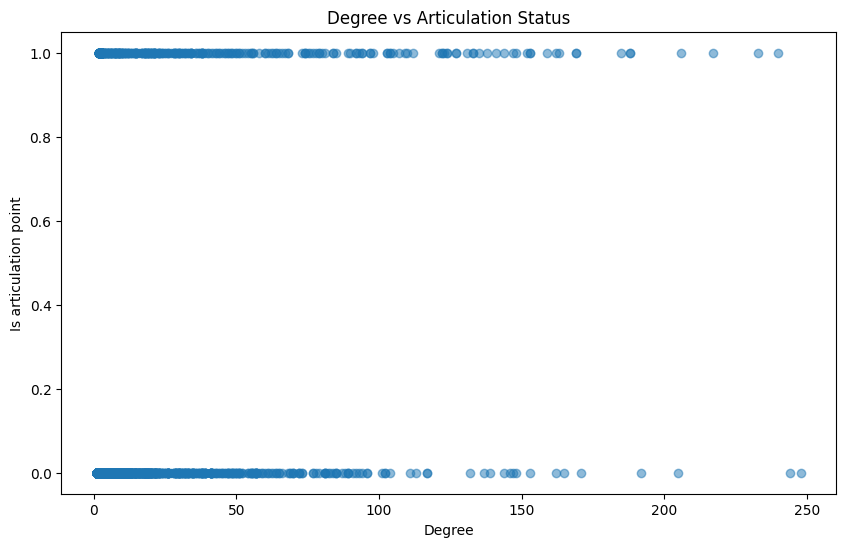

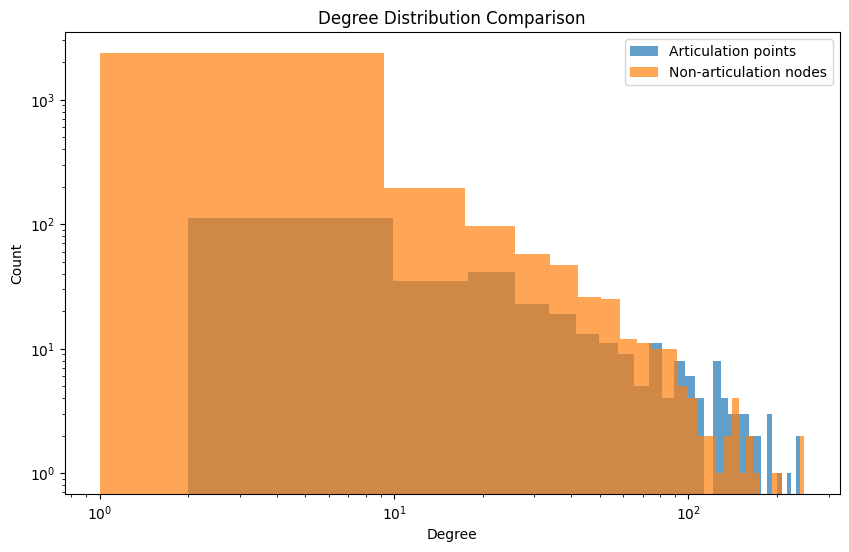

In [240]:
articulation_points = set(nx.articulation_points(G_undirected))

# --------------------------------------------
# Compute node degrees
# --------------------------------------------

degrees = dict(G_undirected.degree())

# --------------------------------------------
# Build dataframe
# --------------------------------------------

rows = []

for node in G_undirected.nodes():

    rows.append({
        "node_id": node,
        "airport_name": id_to_name.get(node, "Unknown"),
        "degree": degrees[node],
        "is_articulation": int(node in articulation_points)
    })

df = pd.DataFrame(rows)

# --------------------------------------------
# Basic statistics
# --------------------------------------------

print("\n=== BASIC STATISTICS ===\n")

print(df.groupby("is_articulation")["degree"].describe())

# --------------------------------------------
# Correlation
# --------------------------------------------

correlation = df["degree"].corr(df["is_articulation"])

print("\n=== CORRELATION ===\n")
print(f"Correlation between degree and articulation status: {correlation:.4f}")

# --------------------------------------------
# Mean degrees
# --------------------------------------------

mean_art = df[df["is_articulation"] == 1]["degree"].mean()
mean_non = df[df["is_articulation"] == 0]["degree"].mean()

print("\n=== MEAN DEGREE ===\n")
print(f"Articulation points mean degree: {mean_art:.2f}")
print(f"Non-articulation nodes mean degree: {mean_non:.2f}")

# --------------------------------------------
# Top articulation points by degree
# --------------------------------------------

print("\n=== TOP ARTICULATION POINTS BY DEGREE ===\n")

top_articulations = (
    df[df["is_articulation"] == 1]
    .sort_values("degree", ascending=False)
)

print(
    top_articulations[
        ["node_id", "airport_name", "degree"]
    ].head(20)
)

# --------------------------------------------
# Scatter plot
# --------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    df["degree"],
    df["is_articulation"],
    alpha=0.5
)

plt.xlabel("Degree")
plt.ylabel("Is articulation point")
plt.title("Degree vs Articulation Status")

plt.show()

# --------------------------------------------
# Histogram comparison
# --------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    df[df["is_articulation"] == 1]["degree"],
    bins=30,
    alpha=0.7,
    label="Articulation points"
)

plt.hist(
    df[df["is_articulation"] == 0]["degree"],
    bins=30,
    alpha=0.7,
    label="Non-articulation nodes"
)

plt.xlabel("Degree")
plt.ylabel("Count")
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Distribution Comparison")

plt.legend()

plt.show()

In [241]:
def sequential_removal_analysis(G, strategy="highest_degree", seed=42):
    """
    Strategies:
    - "random"
    - "highest_degree"
    - "dynamic_highest_degree"
    - "articulation"
    - "dynamic_articulation"
    - "betweenness"
    - "dynamic_betweenness"
    """

    random.seed(seed)

    G_temp = G.copy()
    original_n = G.number_of_nodes()
    original_size = len(max(nx.connected_components(G_temp), key=len))

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []
    removed_nodes = []

    if strategy == "random":
        removal_order = list(G_temp.nodes())
        random.shuffle(removal_order)

    elif strategy == "highest_degree":
        removal_order = [
            node for node, degree in sorted(
                G_temp.degree,
                key=lambda x: x[1],
                reverse=True
            )
        ]

    elif strategy == "articulation":
        articulations = list(nx.articulation_points(G_temp))

        non_articulations = [
            node for node in G_temp.nodes()
            if node not in articulations
        ]

        removal_order = articulations + non_articulations

    elif strategy == "betweenness":
        betweenness = nx.betweenness_centrality(G_temp)

        removal_order = [
            node for node, value in sorted(
                betweenness.items(),
                key=lambda x: x[1],
                reverse=True
            )
        ]

    elif strategy in [
        "dynamic_highest_degree",
        "dynamic_articulation",
        "dynamic_betweenness"
    ]:
        removal_order = None

    else:
        raise ValueError(
            "Unknown strategy. Use: random, highest_degree, "
            "dynamic_highest_degree, articulation, dynamic_articulation, "
            "betweenness, dynamic_betweenness"
        )

    while G_temp.number_of_nodes() > 0:

        if strategy == "dynamic_highest_degree":
            node_to_remove = max(
                G_temp.nodes(),
                key=lambda node: G_temp.degree[node]
            )

        elif strategy == "dynamic_articulation":
            articulations = list(nx.articulation_points(G_temp))

            if len(articulations) > 0:
                node_to_remove = max(
                    articulations,
                    key=lambda node: G_temp.degree[node]
                )
            else:
                node_to_remove = max(
                    G_temp.nodes(),
                    key=lambda node: G_temp.degree[node]
                )

        elif strategy == "dynamic_betweenness":
            betweenness = nx.betweenness_centrality(G_temp)

            node_to_remove = max(
                betweenness,
                key=betweenness.get
            )

        else:
            node_to_remove = removal_order[len(removed_nodes)]

        G_temp.remove_node(node_to_remove)
        removed_nodes.append(node_to_remove)

        if G_temp.number_of_nodes() > 0:
            largest_cc = max(nx.connected_components(G_temp), key=len)
            giant_size = len(largest_cc)
            components_count = nx.number_connected_components(G_temp)
        else:
            giant_size = 0
            components_count = 0

        removed_fraction.append(len(removed_nodes) / original_n)
        giant_component_fraction.append(giant_size / original_size)
        number_of_components.append(components_count)

    return removed_fraction, giant_component_fraction, number_of_components, removed_nodes

In [ ]:
strategies = [
    "random",
    "highest_degree",
    "dynamic_highest_degree",
    "dynamic_articulation",
    "betweenness",
    "dynamic_betweenness"
]

In [ ]:
results = {}

for strategy in strategies:
    print("Running:", strategy)

    results[strategy] = sequential_removal_analysis(
        G_undirected,
        strategy=strategy)

Running: random
Running: highest_degree
Running: dynamic_highest_degree
Running: dynamic_articulation
Running: betweenness
Running: dynamic_betweenness


**Network Robustness Under Node Removal**

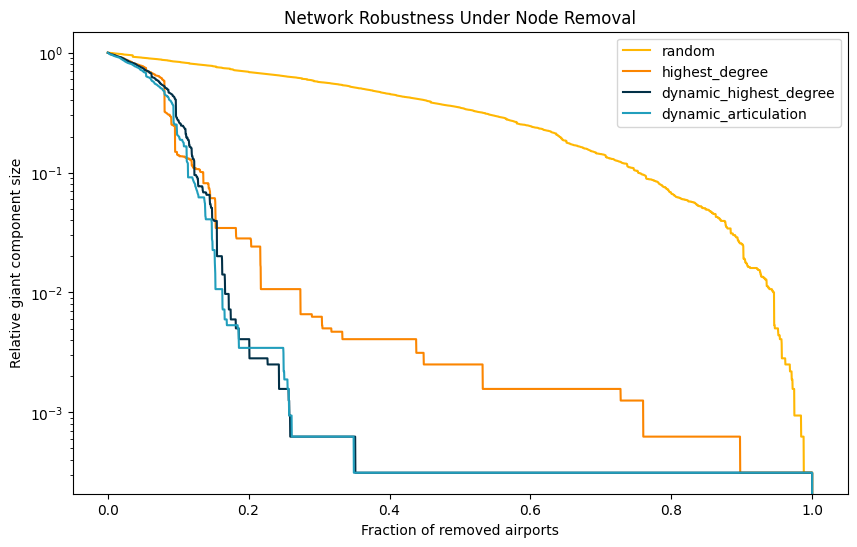

In [ ]:
plt.figure(figsize=(10,6))

colors = {
    "random": "#FFB703",
    "highest_degree": "#FB8500",
    "dynamic_highest_degree": "#023047",
    "dynamic_articulation": "#219EBC",
    "betweenness": "#633658",
    "dynamic_betweenness:": "#DF0505"
}

for strategy in strategies:
    x, y, components, removed = results[strategy]
    plt.plot(x, y, label=strategy, color = colors.get(strategy, None))

plt.xlabel("Fraction of removed airports")
plt.ylabel("Relative giant component size")
plt.title("Network Robustness Under Node Removal")
plt.legend()
plt.yscale("log")
plt.grid(False)
plt.show()

**Network Fragmentation Under Node Removal**

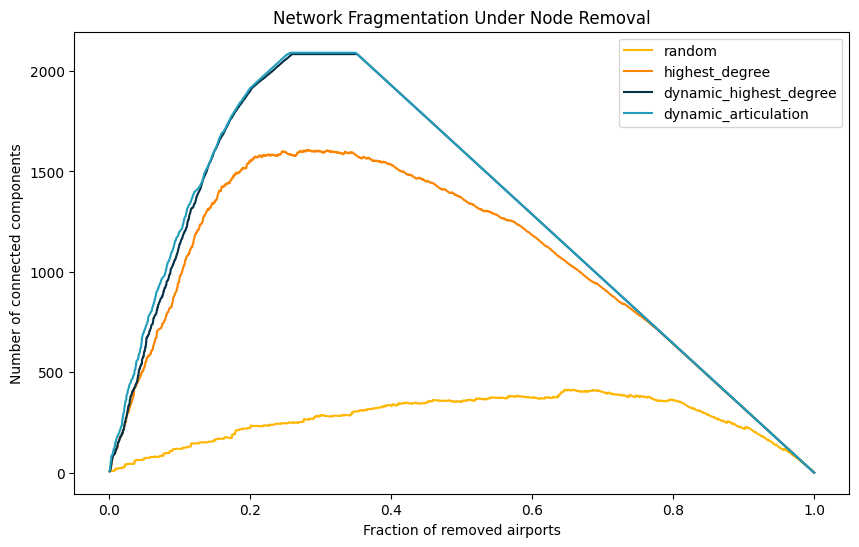

In [195]:
plt.figure(figsize=(10,6))

for strategy in strategies:
    x, y, components, removed = results[strategy]
    plt.plot(x, components, label=strategy, color = colors.get(strategy, None))

plt.xlabel("Fraction of removed airports")
plt.ylabel("Number of connected components")
plt.title("Network Fragmentation Under Node Removal")
plt.legend()
plt.grid(False)
plt.show()

**Difference**

In [136]:
(np.array(results["dynamic_highest_degree"][1]) - np.array(results["dynamic_articulation"][1])).mean() * 100



np.float64(0.6545332957520384)

In [137]:
x_deg, y_deg, c_deg, r_deg = results["dynamic_highest_degree"]
x_art, y_art, c_art, r_art = results["dynamic_articulation"]

# convert to numpy arrays
y_deg = np.array(y_deg)
y_art = np.array(y_art)

# percentage changes
pct_deg = (
    (y_deg[1:] - y_deg[:-1])
    / y_deg[:-1]
) * 100

pct_art = (
    (y_art[1:] - y_art[:-1])
    / y_art[:-1]
) * 100

**Relative percentual drops**

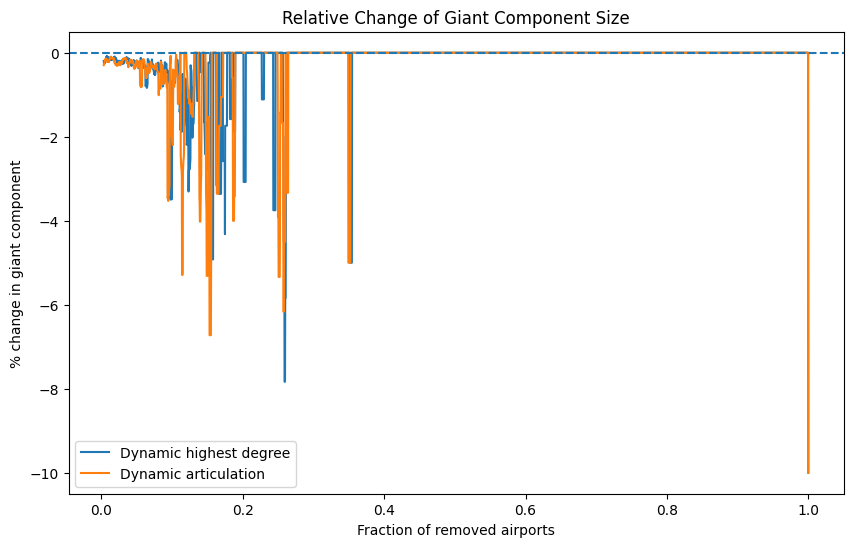

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    x_deg[1:],
    pct_deg,
    label="Dynamic highest degree"
)

plt.plot(
    x_art[1:],
    pct_art,
    label="Dynamic articulation"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fraction of removed airports")
plt.ylabel("% change in giant component")

plt.title(
    "Relative Change of Giant Component Size"
)

plt.legend()
plt.grid(False)

plt.show()

In [149]:
sum(pct_deg) / len(pct_deg), sum(pct_art) / len(pct_art)

(np.float64(-0.2515729523519712), np.float64(-0.25665156398067346))

**a.k.a ROC AUC**

In [154]:
np.trapezoid(y_deg, x_deg)

np.float64(0.07878784122787773)

In [ ]:
np.trapezoid(y_art, x_art) # faster collapse, smaller area

np.float64(0.07224255706878394)

#### **Bridges**

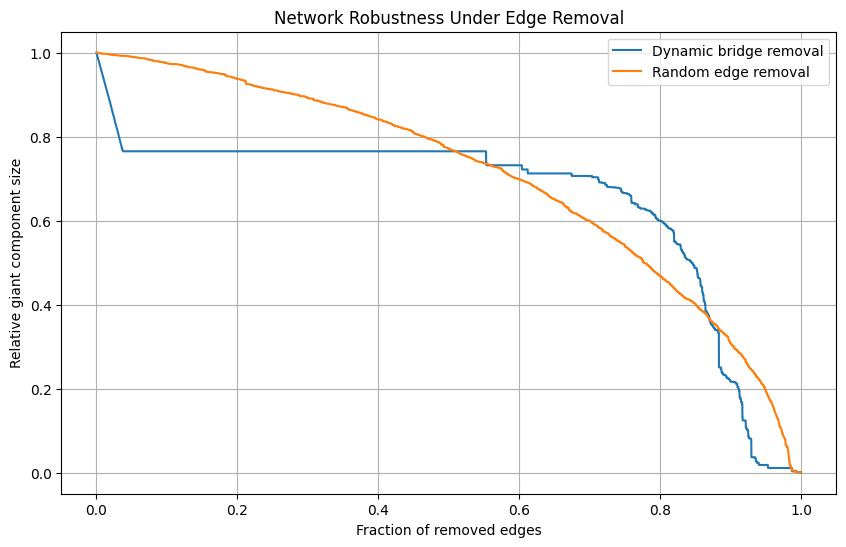

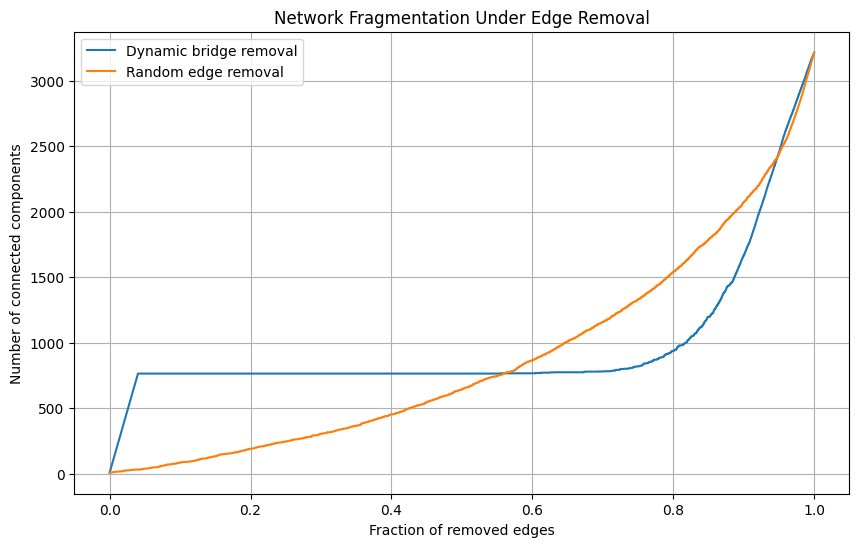

In [ ]:
# ==========================================================
# DYNAMIC BRIDGE REMOVAL
# ==========================================================

def dynamic_bridge_removal_analysis(G, seed=42):

    random.seed(seed)

    G_temp = G.copy()

    original_n = G.number_of_nodes()
    original_size = len(max(nx.connected_components(G_temp), key=len))

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []

    removed_edges = []

    while G_temp.number_of_edges() > 0:

        bridges = list(nx.bridges(G_temp))

        # --------------------------------------------------
        # choose bridge to remove
        # --------------------------------------------------

        if len(bridges) > 0:

            # remove bridge connecting highest-degree vertices
            edge_to_remove = max(
                bridges,
                key=lambda edge:
                    G_temp.degree[edge[0]] +
                    G_temp.degree[edge[1]]
            )

        else:

            # if no bridges remain,
            # remove highest-degree edge
            edge_to_remove = max(
                G_temp.edges(),
                key=lambda edge:
                    G_temp.degree[edge[0]] +
                    G_temp.degree[edge[1]]
            )

        G_temp.remove_edge(*edge_to_remove)

        removed_edges.append(edge_to_remove)

        # --------------------------------------------------
        # metrics
        # --------------------------------------------------

        if G_temp.number_of_nodes() > 0:

            largest_cc = max(
                nx.connected_components(G_temp),
                key=len
            )

            giant_size = len(largest_cc)

            components_count = nx.number_connected_components(G_temp)

        else:

            giant_size = 0
            components_count = 0

        removed_fraction.append(
            len(removed_edges) / G.number_of_edges()
        )

        giant_component_fraction.append(
            giant_size / original_size
        )

        number_of_components.append(
            components_count
        )

    return (
        removed_fraction,
        giant_component_fraction,
        number_of_components,
        removed_edges
    )


# ==========================================================
# RANDOM EDGE REMOVAL
# ==========================================================

def random_edge_removal_analysis(G, seed=42):

    random.seed(seed)

    G_temp = G.copy()

    original_size = len(max(nx.connected_components(G_temp), key=len))

    edges = list(G_temp.edges())
    random.shuffle(edges)

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []

    removed_edges = []

    for edge in edges:

        if G_temp.has_edge(*edge):

            G_temp.remove_edge(*edge)

            removed_edges.append(edge)

            if G_temp.number_of_nodes() > 0:

                largest_cc = max(
                    nx.connected_components(G_temp),
                    key=len
                )

                giant_size = len(largest_cc)

                components_count = nx.number_connected_components(G_temp)

            else:

                giant_size = 0
                components_count = 0

            removed_fraction.append(
                len(removed_edges) / G.number_of_edges()
            )

            giant_component_fraction.append(
                giant_size / original_size
            )

            number_of_components.append(
                components_count
            )

    return (
        removed_fraction,
        giant_component_fraction,
        number_of_components,
        removed_edges
    )


In [ ]:
# run

x_bridge, y_bridge, c_bridge, r_bridge = (
    dynamic_bridge_removal_analysis(G_undirected)
)

x_random, y_random, c_random, r_random = (
    random_edge_removal_analysis(G_undirected)
)

**Network Robustness Under Edge Removal**

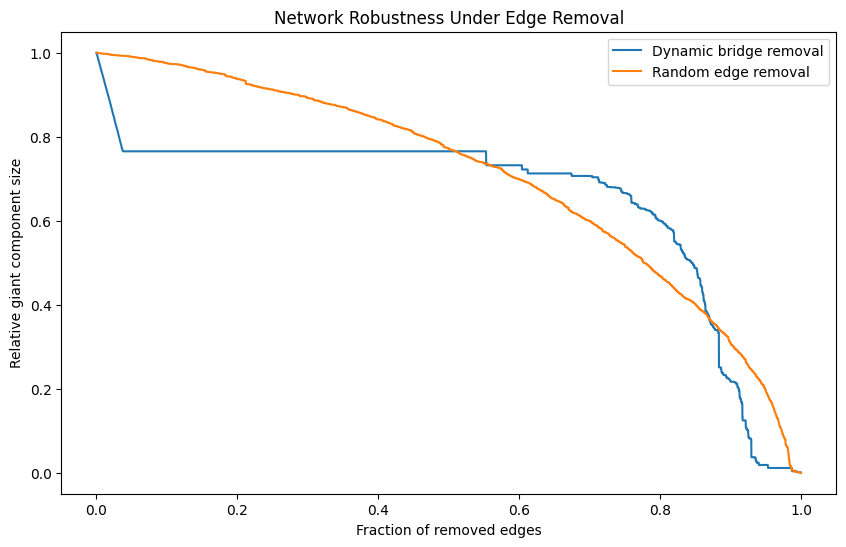

In [184]:
# plot giant component

plt.figure(figsize=(10,6))

plt.plot(
    x_bridge,
    y_bridge,
    label="Dynamic bridge removal"
)

plt.plot(
    x_random,
    y_random,
    label="Random edge removal"
)

plt.xlabel("Fraction of removed edges")
plt.ylabel("Relative giant component size")

plt.title(
    "Network Robustness Under Edge Removal"
)

plt.legend()
plt.grid(False)

plt.show()

**Network Fragmentation Under Edge Removal**

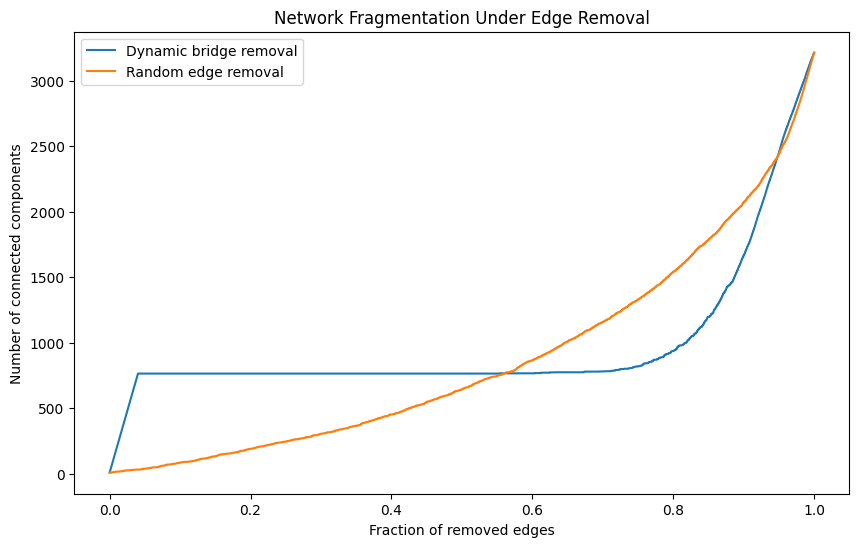

In [181]:
# plot connected components

plt.figure(figsize=(10,6))

plt.plot(
    x_bridge,
    c_bridge,
    label="Dynamic bridge removal"
)

plt.plot(
    x_random,
    c_random,
    label="Random edge removal"
)

plt.xlabel("Fraction of removed edges")
plt.ylabel("Number of connected components")

plt.title(
    "Network Fragmentation Under Edge Removal"
)

plt.legend()
plt.grid(False)

plt.show()

#### Other


In [160]:
core_numbers = nx.core_number(G_undirected)

core_df = pd.DataFrame({
    "node": list(core_numbers.keys()),
    "airport": [id_to_name.get(n, "Unknown") for n in core_numbers.keys()],
    "core_number": list(core_numbers.values()),
    "degree": [G_undirected.degree[n] for n in core_numbers.keys()]
})

core_df.sort_values("core_number", ascending=False).head(30)

,node,airport,core_number,degree
1435,1435,Sheremetyevo International Airport,31,144
279,279,London Stansted Airport,31,153
245,245,Bristol Airport,31,73
282,282,Amsterdam Airport Schiphol,31,248
1017,1017,Dubai International Airport,31,185
270,270,Glasgow International Airport,31,63
242,242,Manchester Airport,31,148
597,597,Toulouse-Blagnac Airport,31,47
1408,1408,Pulkovo Airport,31,112
271,271,Edinburgh Airport,31,89


In [161]:
node_country = dict(zip(nodes[" id"].astype(int), nodes[" country"]))

country_art = pd.DataFrame({
    "node": list(articulation_points),
    "airport": [id_to_name.get(n, "Unknown") for n in articulation_points],
    "country": [node_country.get(n, "Unknown") for n in articulation_points],
    "degree": [G_undirected.degree[n] for n in articulation_points]
})

country_art["country"].value_counts().head(20)

country
United States       62
Brazil              21
Canada              21
Australia           17
Russia              12
China               10
Indonesia            9
Greenland            7
Colombia             7
United Kingdom       6
France               6
India                5
Sweden               4
Congo (Kinshasa)     4
Spain                4
Burma                4
Malaysia             4
Philippines          3
Vanuatu              3
Algeria              3
Name: count, dtype: int64

**Top Countries by Number of Airports**

In [202]:
top_countries = (nodes[" country"].value_counts().head(10))
print(top_countries)

 country
United States    549
Canada           206
China            173
Brazil           122
Australia        113
Russia           103
India             68
Indonesia         63
Japan             62
Mexico            56
Name: count, dtype: int64


**Number of Airports vs. Number of Articulations by Country**

Correlation: 0.9673


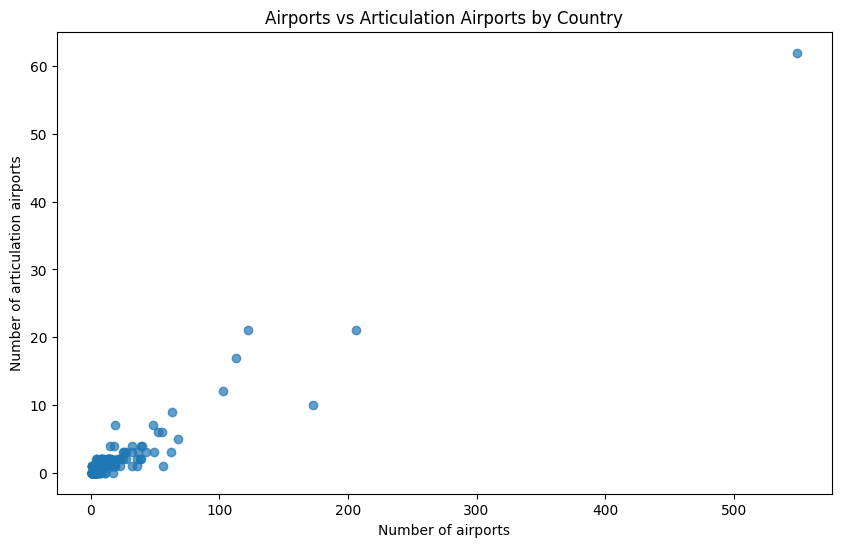

In [206]:
node_country = dict(zip(nodes[" id"].astype(int), nodes[" country"]))

airports_per_country = (
    nodes[" country"]
    .value_counts()
    .reset_index()
)

airports_per_country.columns = ["country", "num_airports"]

articulation_country_df = pd.DataFrame({
    "node": list(articulation_points),
    "country": [
        node_country.get(node, "Unknown")
        for node in articulation_points
    ]
})

articulations_per_country = (
    articulation_country_df["country"]
    .value_counts()
    .reset_index()
)

articulations_per_country.columns = ["country", "num_articulations"]

# merge
country_df = pd.merge(
    airports_per_country,
    articulations_per_country,
    on="country",
    how="left"
)

country_df["num_articulations"] = (country_df["num_articulations"].fillna(0))

# Correlation
correlation = country_df["num_airports"].corr(country_df["num_articulations"])
print(f"Correlation: {correlation:.4f}")

plt.figure(figsize=(10,6))
plt.scatter(
    country_df["num_airports"],
    country_df["num_articulations"],
    alpha=0.7
)

plt.xlabel("Number of airports")
plt.ylabel("Number of articulation airports")
plt.title("Airports vs Articulation Airports by Country")

plt.grid(False)
plt.show()

**Leaf Airports**

In [203]:
leaf_airports = []

for node, degree in G_undirected.degree():
    if degree == 1:
        leaf_airports.append({
            "node_id": node,
            "airport_name": id_to_name.get(node, "Unknown"),
            "country": node_country.get(node, "Unknown")
        })

leaf_df = pd.DataFrame(leaf_airports)

print(f"Number of leaf airports: {len(leaf_df)}")
print(leaf_df.head(30))

Number of leaf airports: 718
    node_id                              airport_name    country
0         9                            Thule Air Base  Greenland
1        10                          Akureyri Airport    Iceland
2        11                       Egilsstaðir Airport    Iceland
3        12                        Ísafjörður Airport    Iceland
4        21                 Brandon Municipal Airport     Canada
5        37                      Fort Simpson Airport     Canada
6        38            Kingston Norman Rogers Airport     Canada
7        54                      Lloydminster Airport     Canada
8        63                     Prince Rupert Airport     Canada
9        69                 Lethbridge County Airport     Canada
10       88                       Tuktoyaktuk Airport     Canada
11       93                      Qikiqtarjuaq Airport     Canada
12      103                      Medicine Hat Airport     Canada
13      116                         Penticton Airport     Can

**How many bridges are leaf related?**

Large number of non-leaf bridges means:

the network contains vulnerable regional bottlenecks beyond simple peripheral airports.

In [ ]:
leaf_bridge_count = 0
non_leaf_bridge_count = 0

for u, v in bridges:
    if (G_undirected.degree[u] == 1 or G_undirected.degree[v] == 1):
        leaf_bridge_count += 1
    else:
        non_leaf_bridge_count += 1

print("Leaf-related bridges:", leaf_bridge_count)
print("Non-leaf bridges:", non_leaf_bridge_count)

Leaf-related bridges: 716
Non-leaf bridges: 41
